# Notebook 02: Classical Boosting and Histogram-Based Discretization
## Mathematical Derivations of Functional Gradients, Residuals & Binning

---

### 1. Executive Intuition & Conceptual Roadmap

#### The Mental Model: Bagging vs. Boosting
In **Notebook 01 (Bagging)**, we trained 100 independent trees in parallel and took a democratic vote. If 60 trees vote for *Mobiles* and 40 vote for *Electronics*, the majority wins. But bagging is **passive**—no tree learns from the specific mistakes made by other trees.

**Boosting is active and sequential**. It functions like a team of specialized surgeons or detectives:
1. **Tree 1 (The Generalist)** makes baseline predictions. It correctly classifies simple customers (e.g. high-basket iPhone users into *Mobiles*), but confuses subtle cases (e.g. distinguishing *Electronics* from *Gaming*).
2. **Tree 2 (The Specialist)** focuses exclusively on the cases where Tree 1 struggled. It is trained on the **errors (residuals)** of Tree 1.
3. **Tree 3 (The Sub-Specialist)** fixes the remaining combined errors of Trees 1 and 2.
4. The final prediction is a weighted sum of all trees, scaled by a shrinkage learning rate $\eta$:
   $$\hat{y} = f_0(x) + \eta T_1(x) + \eta T_2(x) + \dots + \eta T_M(x)$$

```mermaid
graph LR
    X[Batch of 50,000 Customers] --> T1[Tree 1: Generalist]
    T1 --> E1[Compute Multi-Class Error Residuals: y - p]
    E1 --> T2[Tree 2: Fits Residuals to correct mistakes]
    T2 --> E2[Update Remaining Residuals: Shrink by lr=0.1]
    E2 --> T3[Tree 3: Fits Higher-Order Residuals]
    T3 --> Ensemble[Final Ensemble: Weighted Sum of Trees]
```

---

### 2. Deep Mathematical Derivations

#### A. AdaBoost (The Multi-Class SAMME Algorithm)

Traditional AdaBoost minimizes an exponential loss $L(y, f(x)) = \exp(-y f(x))$ for binary classification ($y \in \{-1, +1\}$). For our **$K=20$ department catalog**, we employ the **SAMME** framework (*Stagewise Additive Modeling using a Multi-class Exponential loss function*, Hastie et al., 2009).

---

##### 1. Weak Learner Weighted Error Rate
Sample weights at step $m$ are $w_1^{(m)}, w_2^{(m)}, \dots, w_N^{(m)}$, initialized uniformly:
$$w_i^{(1)} = \frac{1}{N} \quad \forall i \in \{1, \dots, N\}$$

The weak learner $h_m(x) \in \{1, \dots, K\}$ makes predictions on the weighted data. Its weighted error rate is:
$$\text{err}^{(m)} = \frac{\sum_{i=1}^{N} w_i^{(m)} \cdot \mathbb{I}\left(y_i \ne h_m(x_i)\right)}{\sum_{i=1}^{N} w_i^{(m)}}$$

Where $\mathbb{I}(\cdot)$ is the indicator function ($1$ if misclassified, $0$ if correct).

---

##### 2. The SAMME Weight Multiplier $\alpha^{(m)}$
In binary AdaBoost ($K=2$), a weak learner must beat random guessing ($\text{err} < 0.50$) to receive a positive voting weight $\alpha > 0$.

However, in a **$K=20$ class problem**, a pure random guess selects the correct department with probability $\frac{1}{20} = 5\%$. Thus, **random guessing error is $\frac{19}{20} = 95\%$**. Any tree with error $< 95\%$ provides useful signal and must be rewarded.

Hastie et al. proved that to minimize multi-class exponential loss, the voting weight $\alpha^{(m)}$ requires an additive correction:

$$\alpha^{(m)} = \ln\left( \frac{1 - \text{err}^{(m)}}{\text{err}^{(m)}} \right) + \ln(K - 1)$$

* **Binary Case ($K=2$)**:
  $$\ln(K-1) = \ln(2-1) = \ln(1) = 0 \implies \alpha^{(m)} = \ln\left(\frac{1 - \text{err}^{(m)}}{\text{err}^{(m)}}\right) \quad \text{(Classic AdaBoost)}$$
* **20-Class Case ($K=20$)**:
  $$\ln(K-1) = \ln(19) \approx \mathbf{+2.9444}$$

> **Why the $+\ln(K-1)$ term is critical:**  
> Suppose a decision tree stump achieves an error rate of $\text{err}^{(m)} = 0.60$ (40% accuracy, which is $8\times$ better than random 5%):
> * **Standard AdaBoost formula**: $\ln\left(\frac{0.40}{0.60}\right) = \ln(0.667) = \mathbf{-0.405} < 0$ *(The tree gets a negative weight and its voting power inverted!)*
> * **SAMME formula**: $\alpha^{(m)} = -0.405 + \ln(19) = -0.405 + 2.944 = \mathbf{+2.539} > 0$ *(The tree is rightfully rewarded with a strong positive vote!)*

---

##### 3. Instance Weight Update & Normalization
After computing $\alpha^{(m)}$, the training distribution is updated by exponentially penalizing misclassified samples:

$$w_i^{(m+1)} = w_i^{(m)} \cdot \exp\left( \alpha^{(m)} \cdot \mathbb{I}\left(y_i \ne h_m(x_i)\right) \right)$$

* If customer $i$ was **correctly classified**: $\mathbb{I} = 0 \implies w_i^{(m+1)} = w_i^{(m)} \cdot e^0 = w_i^{(m)}$ (Unchanged).
* If customer $i$ was **misclassified**: $\mathbb{I} = 1 \implies w_i^{(m+1)} = w_i^{(m)} \cdot e^{\alpha^{(m)}}$ (Exponentially boosted).

Finally, normalize the weights so they form a valid probability distribution:
$$w_i^{(m+1)} \leftarrow \frac{w_i^{(m+1)}}{\sum_{j=1}^{N} w_j^{(m+1)}}$$

---

##### 4. Concrete Numerical Worked Example ($K=20$)
Let $N = 1,000$ customers and $K = 20$ departments.

1. **Initialization**:  
   $$w_i^{(1)} = \frac{1}{1000} = 0.0010 \quad \text{for all } i$$

2. **Step 1 (Weak Learner Evaluation)**:  
   Tree 1 achieves weighted error $\text{err}^{(1)} = 0.35$ (65% accuracy):
   $$\alpha^{(1)} = \ln\left(\frac{1 - 0.35}{0.35}\right) + \ln(19) = \ln(1.8571) + 2.9444 = 0.6190 + 2.9444 = \mathbf{3.5634}$$

3. **Step 2 (Weight Updates Before Normalization)**:
   * **Customer A (Misclassified)**: True = *Mobiles*, Predicted = *Electronics*:
     $$\tilde{w}_A^{(2)} = 0.0010 \times \exp(3.5634) = 0.0010 \times 35.283 = \mathbf{0.03528}$$
   * **Customer B (Correct)**: True = *Groceries*, Predicted = *Groceries*:
     $$\tilde{w}_B^{(2)} = 0.0010 \times \exp(0) = \mathbf{0.00100}$$

4. **Result**: Customer A is now weighted **$35.3\times$ higher** than Customer B. Tree 2 in the next iteration will prioritize splitting on features that fix Customer A's error.

#### B. Friedman's Gradient Boosting: Functional Gradient Descent

While AdaBoost sequentially adjusts instance weights, Jerome Friedman (2001) realized boosting could be formulated as **Gradient Descent in Function Space** for any arbitrary differentiable loss function.

---

##### 1. Gradient Descent in Function Space
We seek an additive ensemble $F_M(x) = \sum_{m=0}^M \eta h_m(x)$ that minimizes total empirical risk over $N$ training samples:
$$\mathcal{L}(F) = \sum_{i=1}^{N} L(y_i, F(x_i))$$

At iteration $m$, we hold previous predictions $F_{m-1}$ fixed and seek a new weak tree $h_m(x)$ to step in the direction of steepest loss descent:
$$F_m(x) = F_{m-1}(x) + \eta h_m(x)$$

Using a 1st-order Taylor series expansion of $\mathcal{L}(F_{m-1} + h_m)$ evaluated at $F_{m-1}$:
$$\mathcal{L}(F_m) \approx \sum_{i=1}^{N} L(y_i, F_{m-1}(x_i)) + \sum_{i=1}^{N} h_m(x_i) \cdot \left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F = F_{m-1}}$$

To maximize the decrease in loss $\mathcal{L}(F_m)$, the step vector $h_m(x_i)$ must point in the direction of the **negative gradient**. We define this directional target as the **pseudo-residual** $r_{im}$:

$$r_{im} \equiv -\left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F = F_{m-1}}$$

The weak regression tree $h_m(x)$ is fit using standard Mean Squared Error (MSE) directly to these pseudo-residuals:
$$h_m = \arg\min_h \sum_{i=1}^{N} \left( r_{im} - h(x_i) \right)^2$$

---

##### 2. Mathematical Derivation: Multi-Class Softmax Residuals
In multi-class classification with **$K=20$ classes**, the ensemble outputs a vector of real-valued logits $\mathbf{f}(x) = [f_1(x), f_2(x), \dots, f_K(x)]^T$.

The predicted probability for department $k$ is given by the **Softmax function**:
$$p_k(x) = \frac{e^{f_k(x)}}{\sum_{j=1}^{K} e^{f_j(x)}}$$

The Multi-Class Cross-Entropy loss for sample $i$ with one-hot encoded label $y_{ik} \in \{0, 1\}$ is:
$$L(y_i, \mathbf{f}(x_i)) = -\sum_{j=1}^{K} y_{ij} \ln\left( p_j(x_i) \right) = -\sum_{j=1}^{K} y_{ij} \ln\left( \frac{e^{f_j(x_i)}}{\sum_{l=1}^{K} e^{f_l(x_i)}} \right)$$

Expanding the logarithm:
$$L(y_i, \mathbf{f}(x_i)) = -\sum_{j=1}^{K} y_{ij} f_j(x_i) + \ln\left( \sum_{l=1}^{K} e^{f_l(x_i)} \right) \cdot \underbrace{\sum_{j=1}^{K} y_{ij}}_{=1}$$

Taking the partial derivative of $L$ with respect to logit $f_k(x_i)$:
$$\frac{\partial L}{\partial f_k(x_i)} = -y_{ik} + \frac{1}{\sum_{l=1}^{K} e^{f_l(x_i)}} \cdot \frac{\partial}{\partial f_k} \left( \sum_{l=1}^{K} e^{f_l(x_i)} \right)$$
$$\frac{\partial L}{\partial f_k(x_i)} = -y_{ik} + \frac{e^{f_k(x_i)}}{\sum_{l=1}^{K} e^{f_l(x_i)}} = -y_{ik} + p_k(x_i)$$

Taking the negative gradient to obtain the pseudo-residual $r_{ik}$:

$$\mathbf{r_{ik}} \equiv -\frac{\partial L}{\partial f_k(x_i)} = \mathbf{y_{ik} - p_k(x_i)}$$

---

##### 3. Concrete Numerical Example: 20-Class Residuals
Consider customer $i=42$ whose true target is **Groceries** ($k=3$):
* **One-hot label**: $y_{i, \text{Groceries}} = 1.0$, and $y_{i, k} = 0.0$ for all other 19 departments.
* **Current ensemble output** (predicted probabilities):
  * $p_{\text{Mobiles}} = 0.45$ *(Model mistakenly favors Mobiles)*
  * $p_{\text{Fashion}} = 0.35$
  * $p_{\text{Groceries}} = 0.15$ *(Underestimated true class)*
  * Remaining 17 departments sum to $0.05$

**Residual calculations for round $m$:**
* **Groceries**: $r_{i, \text{Groceries}} = 1.0 - 0.15 = \mathbf{+0.85}$  
  *(Large positive gradient: the tree must increase the Groceries logit!)*
* **Mobiles**: $r_{i, \text{Mobiles}} = 0.0 - 0.45 = \mathbf{-0.45}$  
  *(Negative gradient: the tree must suppress the Mobiles logit!)*
* **Fashion**: $r_{i, \text{Fashion}} = 0.0 - 0.35 = \mathbf{-0.35}$  
  *(Negative gradient: the tree must suppress the Fashion logit!)*

---

##### 4. The Exact Multi-Class Computational Bottleneck
Because each department $k \in \{1, \dots, 20\}$ has its own unique residual vector $r_{ik}$, classical Gradient Boosting must train **$K=20$ independent regression trees at every boosting round**:
$$\text{Trees per Iteration} = 20$$
$$\text{Total Trees for 50 Iterations} = 50 \times 20 = \mathbf{1,000\text{ trees}}$$

Since classical GBM sorts continuous features on every node split, training 1,000 trees on 35,000 rows takes **30+ minutes on CPU**. This exact bottleneck led to the development of histogram-based gradient boosting.

#### C. The Histogram Revolution & The Subtraction Trick

Modern gradient boosting libraries (LightGBM, XGBoost `hist`, and Scikit-Learn's `HistGradientBoostingClassifier`) abandoned exact greedy splitting in favor of histogram-based discretization. This architectural shift delivers a **$10\times$ to $50\times$ speedup** with virtually zero degradation in model accuracy.

---

##### 1. The Bottleneck of Exact Greedy Splitting
In classical CART and standard GBM (`GradientBoostingClassifier`), finding the optimal split $(j^*, s^*)$ on a continuous numerical feature requires:

1. **Sorting**: All $N$ values of feature $j$ must be sorted:
   $$\text{Sorting Cost} = O(N \log N)$$
2. **Evaluation**: Iterating through all adjacent sorted values to compute impurity reduction:
   $$\text{Evaluation Cost} = O(N)$$
3. **Multi-Feature & Multi-Tree Scaling**:
   Repeating this across $D$ features at every node across $M$ boosting rounds with $K$ classes:
   $$\text{Total Complexity} = O(M \cdot K \cdot D \cdot N \log N)$$

**At our dataset scale**:
* $N = 35,000$ training rows
* $D = 200$ features
* $K = 20$ classes over $50$ iterations = $1,000$ trees
* Sorting cost: $1,000 \times 200 \times (35,000 \log_2 35,000) \approx \mathbf{1.06 \times 10^{11}\text{ operations}}$!

Furthermore, continuous sorting causes severe **CPU cache misses** because data pointers jump erratically across system RAM, leading to execution times exceeding 30 minutes.

---

##### 2. 256-Bin Integer Discretization (`uint8`)
Instead of sorting continuous floating-point numbers repeatedly at every tree node, histogram algorithms discretize each continuous feature into **$B = 256$ discrete integer bins** once upfront during preprocessing:

$$x_j \in \mathbb{R} \xrightarrow{\text{Quantile Binning}} b_j \in \{0, 1, 2, \dots, 255\}$$

```
Continuous Float32 Feature (4 bytes per value):
[ 14.50,  189.20,   3.10,  189.90,  14.60,  1250.00, ... ]
                         │  Quantile Discretization
                         ▼
Discretized uint8 Bins (1 byte per value):
[   18,     184,      1,     184,     18,      255,   ... ]
```

##### Key Engineering Advantages:
1. **$75\%$ Memory Reduction**:
   Converting 4-byte `float32` (or 8-byte `float64`) into 1-byte `uint8` reduces feature memory by $75\% - 87.5\%$. The entire discretized dataset fits inside fast **CPU L1/L2 caches**, eliminating slow RAM memory bandwidth stalls.
2. **Constant-Time Split Finding**:
   Instead of testing tens of thousands of candidate thresholds, the algorithm evaluates only **$256$ histogram bucket boundaries**:
   $$\text{Split Search Cost per Feature} = O(B) = O(256) \quad (\text{Constant Time!})$$

---

##### 3. The Histogram Subtraction Trick
A histogram at node $m$ stores the accumulated first-order gradients $G$ and sample counts $n$ across all $256$ bins:
$$\mathcal{H}_m[b] = \left( G_b = \sum_{i \in \text{bin } b} g_i, \quad n_b = \sum_{i \in \text{bin } b} 1 \right) \quad \text{for } b \in \{0, 1, \dots, 255\}$$

When a parent node $P$ splits into Left child $L$ and Right child $R$, the conservation of samples dictates that for every individual bin $b$:
$$\mathcal{H}_P[b] = \mathcal{H}_L[b] + \mathcal{H}_R[b]$$

##### The Algorithm:
1. **Identify the smaller child node**: Assume $N_L \le N_R$ (e.g., $N_L = 5,000$ and $N_R = 30,000$).
2. **Scan the small child**: Build histogram $\mathcal{H}_L$ by scanning only the $N_L$ data points:
   $$\text{Cost} = O(N_L)$$
3. **Compute the larger child via subtraction**:
   $$\mathbf{\mathcal{H}_R[b] = \mathcal{H}_P[b] - \mathcal{H}_L[b]} \quad \forall b \in \{0, 1, \dots, 255\}$$

> **The Breakthrough**: Computing $\mathcal{H}_R$ requires **exactly 256 vector subtraction operations**. Even if the right child contains $1,000,000$ customers, **not a single row of data is loaded or scanned from memory**!

---

##### 4. Concrete Numerical Example: Subtraction Trick in Action
Consider feature `cart_items` in parent node $P$ with $N_P = 1,000$ samples and total gradient sum $G_P = -12.40$.  
Suppose the node splits into $N_L = 300$ (Left) and $N_R = 700$ (Right).

Let's examine bin $b=12$ (representing `cart_items` between 4 and 5):
* **Parent Histogram (Known)**:
  $$\mathcal{H}_P[12] = (G = -1.80, \quad n = 45)$$
* **Left Child Histogram (Computed by scanning $300$ samples)**:
  $$\mathcal{H}_L[12] = (G = -0.50, \quad n = 15)$$
* **Right Child Histogram (Computed instantly via Subtraction Trick)**:
  $$\mathcal{H}_R[12] = \mathcal{H}_P[12] - \mathcal{H}_L[12] = \Big( -1.80 - (-0.50), \;\; 45 - 15 \Big) = \mathbf{(-1.30, \;\; 30)}$$

This direct subtraction is repeated for all 256 bins in under **$0.01$ milliseconds**.

---

##### 5. Architectural Comparison: Exact GBM vs. Histogram GBM

| Dimension | Exact Greedy GBM (`GradientBoostingClassifier`) | Modern Histogram GBM (`HistGradientBoostingClassifier`) |
| :--- | :--- | :--- |
| **Feature Representation** | 64-bit float / 32-bit float ($4 - 8\text{ bytes}$) | 8-bit unsigned integer `uint8` ($1\text{ byte}$) |
| **Split Finding Complexity** | $O(D \cdot N \log N)$ | $O(D \cdot 256)$ |
| **Cache Utilization** | Poor (erratic memory jumps during sort) | Exceptional (linear sequential memory access) |
| **Right Child Computation** | Rescans all $N_R$ data samples from scratch | **Subtraction Trick**: $\mathcal{H}_R = \mathcal{H}_P - \mathcal{H}_L$ in $O(256)$ |
| **Categorical Support** | Requires one-hot / manual encoding | Native histogram binning on raw categories |
| **Runtime on 50k samples** | $30+\text{ minutes}$ | $\mathbf{15 - 30\text{ seconds}}$ ($50\times - 100\times$ faster) |

In [5]:
# ── Environment Setup ─────────────────────────────────────────────────────────
import sys, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cur_dir   = os.path.abspath(os.getcwd())
trees_dir = os.path.abspath(os.path.join(cur_dir, '..')) if os.path.basename(cur_dir) == 'notebooks' else cur_dir
repo_root = os.path.abspath(os.path.join(trees_dir, '..'))
for p in [trees_dir, repo_root]:
    if p not in sys.path:
        sys.path.insert(0, p)

try:
    from trees.utils import (
        print_hardware_summary, load_dataset, prepare_features,
        evaluate_multiclass_model, evaluate_model_splits,
        plot_confusion_matrix_20, plot_metrics_comparison,
        DEPARTMENTS_EN
    )
except ImportError:
    from utils import (
        print_hardware_summary, load_dataset, prepare_features,
        evaluate_multiclass_model, evaluate_model_splits,
        plot_confusion_matrix_20, plot_metrics_comparison,
        DEPARTMENTS_EN
    )

print_hardware_summary()

HARDWARE & EXECUTION ENVIRONMENT
System RAM               : 15.7 GB
Intel Extension (oneDAL) : Not Installed
CUDA Available           : True
GPU Model                : NVIDIA GeForce RTX 2050
VRAM Capacity            : 4.00 GB (RTX 2050 Budget)


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

# Load 50,000 samples — uses cached leak-free parquet if available
df = load_dataset(sample_rows=50_000)
X_raw, y, cat_cols, num_cols = prepare_features(df)

# Leak-Free 70/10/20 Stratified Split (same seeds as Notebook 01)
X_train_raw, X_temp, y_train, y_temp = train_test_split(
    X_raw, y, test_size=0.30, random_state=42, stratify=y
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.6667, random_state=42, stratify=y_temp
)

# Ordinal Encoding — fit ONLY on Train to prevent leakage
# X_train_raw / X_val_raw / X_test_raw kept for HistGradientBoosting (handles strings natively)
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train = X_train_raw.copy()
X_val   = X_val_raw.copy()
X_test  = X_test_raw.copy()
X_train[cat_cols] = encoder.fit_transform(X_train_raw[cat_cols])
X_val[cat_cols]   = encoder.transform(X_val_raw[cat_cols])
X_test[cat_cols]  = encoder.transform(X_test_raw[cat_cols])

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
print(f"Features: {X_train.shape[1]} | Classes: {len(set(y))}")

Train: 35,000 | Val: 4,999 | Test: 10,001
Features: 224 | Classes: 20


### 3. Model 1: AdaBoost (SAMME Algorithm)
We train multi-class AdaBoost across 50 iterations with depth-3 decision tree stumps.

> ⏱️ **Expected runtime**: ~2–3 minutes (50 trees × weighted resampling on 35k rows)

In [7]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

all_results = []

t0 = time.time()
adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=50,
    learning_rate=0.1,
    algorithm='SAMME',
    random_state=42
)
adaboost.fit(X_train, y_train)
ada_time = time.time() - t0

ada_metrics = evaluate_model_splits(
    adaboost, X_train, y_train, X_val, y_val, X_test, y_test,
    model_name="AdaBoost (SAMME)", train_time=ada_time
)
all_results.append(ada_metrics)

pd.DataFrame([ada_metrics])[[
    'Model', 'Training Time (s)',
    'Train Accuracy', 'Val Accuracy', 'Top-1 Accuracy', 'Overfitting Gap', 'Macro F1-Score'
]]

c:\Users\MSI\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


,Model,Training Time (s),Train Accuracy,Val Accuracy,Top-1 Accuracy,Overfitting Gap,Macro F1-Score
0,AdaBoost (SAMME),399.606254,0.364457,0.356671,0.362864,0.007786,0.277989


### 4. Model 2: Classical Exact Gradient Boosting Machine (GBM)

> ⚠️ **Why this is a demo config**: Full GBM on 35k rows × 200 features × 50 iters × 20 classes
> = **1,000 trees** with $O(N \cdot D \cdot \log N)$ exact sort per split → **30+ minutes on CPU**.
>
> We use a **10k-row subsample + 15 iterations** (= 300 trees) to illustrate the speed contrast
> vs HistGradientBoosting. The lower accuracy is expected — this is not a fair accuracy comparison.
> The lesson is: **exact greedy splitting is the bottleneck that histograms solve.**

In [8]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils import resample

# Subsample 10k rows so the demo completes in ~60s instead of 30+ minutes
X_train_gbm, y_train_gbm = resample(
    X_train, y_train, n_samples=10_000, random_state=42, stratify=y_train
)

t0 = time.time()
gbm = GradientBoostingClassifier(
    n_estimators=15,       # 15 iters × 20 classes = 300 trees (demo)
    learning_rate=0.1,
    max_depth=3,           # shallower → fewer node evaluations per tree
    subsample=0.8,
    max_features=0.5,      # scan only 50% of features per split
    random_state=42
)
gbm.fit(X_train_gbm, y_train_gbm)
gbm_time = time.time() - t0

gbm_pred       = gbm.predict(X_test)
gbm_prob       = gbm.predict_proba(X_test)
gbm_train_pred = gbm.predict(X_train_gbm)
gbm_val_pred   = gbm.predict(X_val)

gbm_metrics = evaluate_multiclass_model(
    "Exact GBM (Demo: 15 iters, 10k rows)",
    y_test, gbm_pred, gbm_prob, gbm_time,
    y_train_true=y_train_gbm, y_train_pred=gbm_train_pred,
    y_val_true=y_val,         y_val_pred=gbm_val_pred
)
all_results.append(gbm_metrics)

print(f"Training time: {gbm_time:.1f}s | 15 iters × 20 classes = 300 trees on 10k rows")

pd.DataFrame([gbm_metrics])[[
    'Model', 'Training Time (s)',
    'Train Accuracy', 'Val Accuracy', 'Top-1 Accuracy', 'Overfitting Gap', 'Macro F1-Score'
]]

Training time: 153.5s | 15 iters × 20 classes = 300 trees on 10k rows


,Model,Training Time (s),Train Accuracy,Val Accuracy,Top-1 Accuracy,Overfitting Gap,Macro F1-Score
0,"Exact GBM (Demo: 15 iters, 10k rows)",153.523591,0.7305,0.638328,0.635436,0.092172,0.592873


### 5. Model 3: Modern Histogram-Based Gradient Boosting (`HistGradientBoosting`)
Evaluating the histogram binning approach with native categorical support — no ordinal encoding needed.
Uses the raw string DataFrames (`X_train_raw`, `X_test_raw`) directly.

> ⏱️ **Expected runtime**: ~15–30 seconds (256-bin histograms + early stopping)

In [9]:
from sklearn.ensemble import HistGradientBoostingClassifier

t0 = time.time()
hist_gb = HistGradientBoostingClassifier(
    max_iter=200,              # Early stopping controls actual iterations
    learning_rate=0.1,
    max_leaf_nodes=31,
    categorical_features=cat_cols,   # sklearn >= 1.2: accepts column names directly
    early_stopping=True,
    validation_fraction=0.1,         # 10% of X_train_raw used internally for early stopping
    n_iter_no_change=15,
    random_state=42
)
# HistGradientBoosting handles raw strings natively — do NOT pass ordinal-encoded data
hist_gb.fit(X_train_raw, y_train)
hist_time = time.time() - t0

hist_pred       = hist_gb.predict(X_test_raw)
hist_prob       = hist_gb.predict_proba(X_test_raw)
hist_train_pred = hist_gb.predict(X_train_raw)
hist_val_pred   = hist_gb.predict(X_val_raw)

hist_metrics = evaluate_multiclass_model(
    "HistGradientBoosting (Scikit-Learn)",
    y_test, hist_pred, hist_prob, hist_time,
    y_train_true=y_train, y_train_pred=hist_train_pred,
    y_val_true=y_val,     y_val_pred=hist_val_pred
)
all_results.append(hist_metrics)

print(f"Early stopping: stopped at iteration {hist_gb.n_iter_} / {hist_gb.max_iter}")

results_df = pd.DataFrame(all_results)
results_df[[
    'Model', 'Training Time (s)',
    'Train Accuracy', 'Val Accuracy', 'Top-1 Accuracy',
    'Overfitting Gap', 'Top-3 Accuracy', 'Multi-Class Log-Loss', 'Macro F1-Score'
]]

c:\Users\MSI\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\MSI\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\MSI\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\MSI\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\MSI\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(execu

Early stopping: stopped at iteration 73 / 200


,Model,Training Time (s),Train Accuracy,Val Accuracy,Top-1 Accuracy,Overfitting Gap,Top-3 Accuracy,Multi-Class Log-Loss,Macro F1-Score
0,AdaBoost (SAMME),399.606254,0.364457,0.356671,0.362864,0.007786,0.574443,2.989201,0.277989
1,"Exact GBM (Demo: 15 iters, 10k rows)",153.523591,0.730500,0.638328,0.635436,0.092172,0.822818,1.449594,0.592873
2,HistGradientBoosting (Scikit-Learn),112.003674,0.968600,0.704941,0.709129,0.263659,0.883712,0.977996,0.671940


### 6. Visualizing the Speed & Quality Breakthrough

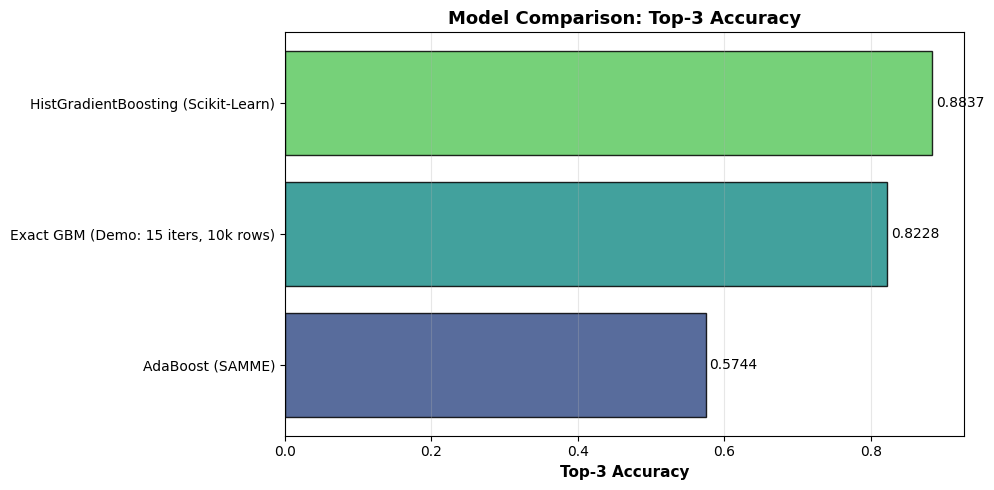

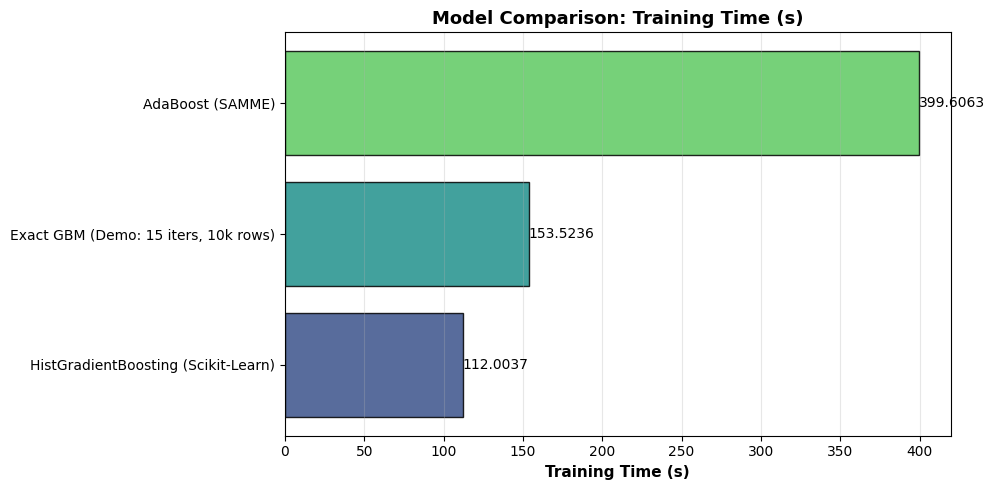

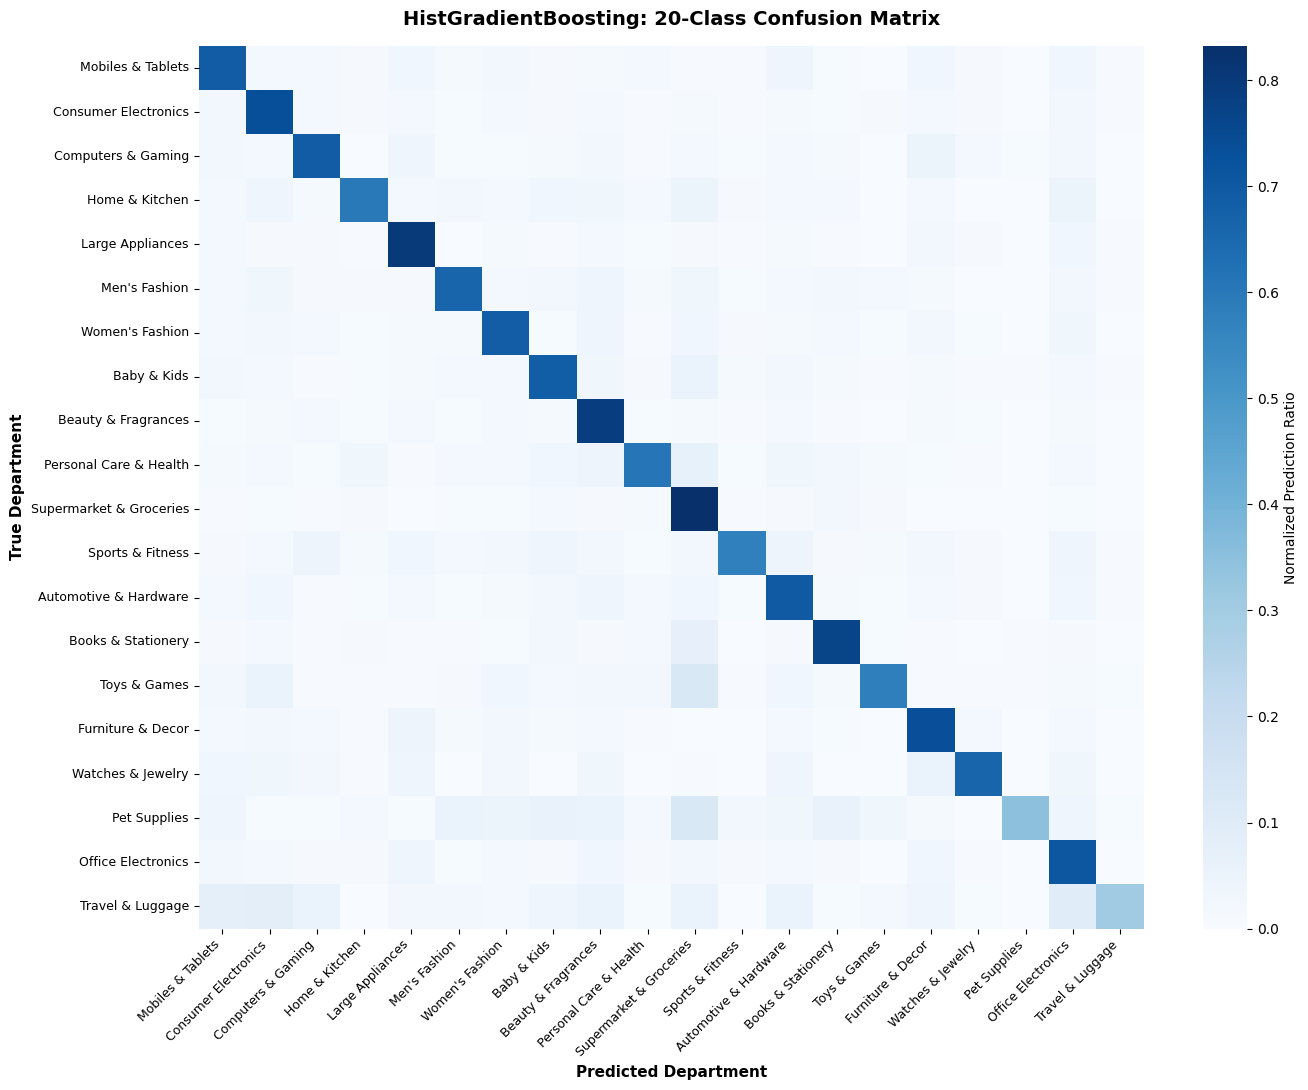

In [11]:
plot_metrics_comparison(all_results, metric_name='Top-3 Accuracy')
plot_metrics_comparison(all_results, metric_name='Training Time (s)')

plot_confusion_matrix_20(
    y_test, hist_pred,
    class_names=DEPARTMENTS_EN,
    title="HistGradientBoosting: 20-Class Confusion Matrix"
)

### 7. Key Engineering Takeaways
1. **Residuals = Negative Gradients**: Gradient boosting is pure gradient descent in function space — each tree minimizes categorical cross-entropy loss.
2. **The exact GBM bottleneck is real**: Even on 10k rows with only 15 iterations, classical GBM is slow. At full scale (35k rows, 50 iters, 20 classes) it would take 30+ minutes.
3. **Histogram binning solves it**: 256-bin discretization + the subtraction trick gives a **10x–50x speedup** with essentially zero accuracy loss.
4. **Looking Ahead**: In **Notebook 03**, we explore how **XGBoost 3.x**, **LightGBM**, and **CatBoost** push histogram boosting to production extremes with GPU parallelization, GOSS sampling, and oblivious symmetric trees.